# Lab Day 1 — MLP và thí nghiệm huấn luyện

Notebook Part 0–4. Chạy cùng các module trong thư mục `code/`. Trên Colab/Kaggle, tải toàn bộ thư mục nộp; giữ thư mục dữ liệu repo bên cạnh thư mục nộp, hoặc đặt `LAB_REPO_ROOT` đến repo có `data/`, `scripts/`, `templates/`. Bật GPU. Cài `pip install -r code/requirements.txt` nếu môi trường thiếu thư viện.

`REUSE_RESULTS=True` đọc lịch sử đo đã lưu và tái tạo bảng/ảnh/báo cáo; không coi việc đọc lịch sử là huấn luyện mới. Để huấn luyện lại, đặt False: kết quả ghi trong thư mục mới, không chỉnh lựa chọn của nghiên cứu đã chấm eval.

In [1]:
from pathlib import Path
import os, sys, json, numpy as np, pandas as pd, torch
from IPython.display import display, Image, Markdown

# If Jupyter starts at the repository root, locate the submitted modules.
CODE_DIR = Path.cwd()
if not (CODE_DIR / "workflow.py").exists():
    matches = sorted(CODE_DIR.glob("submission_*/code/workflow.py"))
    CODE_DIR = matches[0].parent if matches else CODE_DIR / "code"
sys.path.insert(0, str(CODE_DIR.resolve()))
from workflow import Lab
from checks import validate_numerics
from results_table import load_results
REUSE_RESULTS = True
OUT_DIR = CODE_DIR.resolve().parent
if not OUT_DIR.name.startswith("submission_"):
    OUT_DIR = OUT_DIR / "submission_MSSV"
if not REUSE_RESULTS:
    from datetime import datetime
    OUT_DIR = OUT_DIR.parent / (OUT_DIR.name + "_rerun_" + datetime.now().strftime("%Y%m%d_%H%M%S"))
lab = Lab(out=OUT_DIR)
print("PyTorch", torch.__version__, "device", lab.device)
print("Outputs:", OUT_DIR)
validate_numerics()

tr: (371847, 54), counts [135578, 181312, 22882, 1759, 6075, 11115, 13126]
val: (92962, 54), counts [33894, 45328, 5721, 439, 1519, 2779, 3282]
eval: (116203, 54), counts [42368, 56661, 7151, 549, 1899, 3473, 4102]
Majority validation accuracy: 0.487597


PyTorch 2.7.1+cu126 device cuda
Outputs: C:\Users\ACER\K4-Track4-Day1-Neuralnetwork\submission_MSSV
Numerical validation passed: models, CE/MSE uneven batches, F1, pre-clip norm, train-only scaling, CSV.


True

## Part 0 — Dữ liệu

Train/eval theo metadata cố định; validation tách từ train, stratified seed 42. Chỉ chuẩn hóa 10 cột số bằng train sau tách. Giữ mọi dòng ở batch cuối.

In [2]:
for name in ("tr", "val", "eval"):
    print(name, tuple(lab.data[f"X_{name}"].shape), lab.data[f"X_{name}"].dtype, lab.data[f"y_{name}"].dtype)
print("Numeric mean:", lab.data["X_tr"][:, :10].mean(0).cpu().numpy())
print("Numeric std:", lab.data["X_tr"][:, :10].std(0, correction=0).cpu().numpy())
print("Majority val accuracy:", lab.data["majority_val_acc"])

tr (371847, 54) torch.float32 torch.int64
val (92962, 54) torch.float32 torch.int64
eval (116203, 54) torch.float32 torch.int64
Numeric mean: [ 0.0000000e+00  0.0000000e+00 -2.9545291e-09  2.4621077e-10
 -2.2364144e-09  4.1035127e-11 -1.2310539e-10 -2.9545291e-09
 -1.8876158e-09  9.4380792e-10]
Numeric std: [1.         0.9999999  1.         1.         0.99999994 0.99999994
 1.         1.         1.         0.99999994]
Majority val accuracy: 0.4875970826789441


## Part 1 — Model và sức khỏe ban đầu

Dự đoán: logits gần đều cho CE gần ln7; He lớp cuối có thể làm logits không đều. Model đúng phải học thuộc được 20 mẫu và có gradient ở mọi tham số.

Reuse health: 47879 parameters, step0=2.269062, overfit20=0.00000063


,layer,shape
0,Linear,"[8, 256]"
1,ReLU,"[8, 256]"
2,Dropout,"[8, 256]"
3,Linear,"[8, 128]"
4,ReLU,"[8, 128]"
5,Dropout,"[8, 128]"
6,Linear,"[8, 7]"


Parameters: 47879 step0: 2.2690617201114436 ln7: 1.9459101490553132
Gradient norms: {'net.0.weight': 0.5070549845695496, 'net.0.bias': 0.3422401249408722, 'net.3.weight': 2.021228551864624, 'net.3.bias': 0.44387364387512207, 'net.6.weight': 1.9604556560516357, 'net.6.bias': 0.5724555850028992}
Overfit loss/acc: 6.318086889223196e-07 1.0


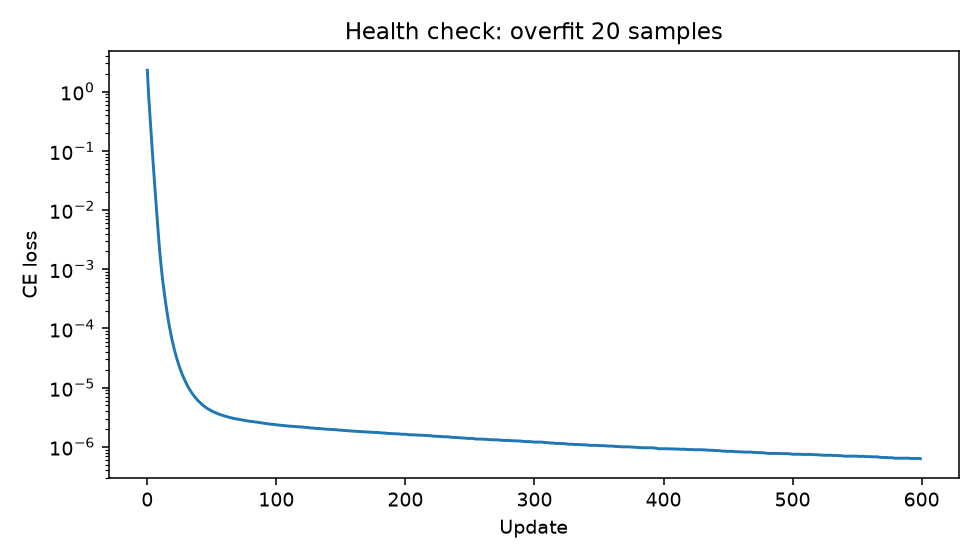

,activation_std,step0_ce
he,"[0.3904455602169037, 0.36608922481536865, 0.57...",2.269062
xavier,"[0.1629583090543747, 0.12475481629371643, 0.19...",2.022176
normal,"[0.020288147032260895, 0.0021521563176065683, ...",1.945996
zeros,"[0.0, 0.0, 0.0]",1.945915


In [3]:
health = lab.health()
display(pd.DataFrame(health["shapes"], columns=["layer", "shape"]))
print("Parameters:", health["parameters"], "step0:", health["step0_loss"], "ln7:", np.log(7))
print("Gradient norms:", health["grad_norms"])
print("Overfit loss/acc:", health["overfit_loss"], health["overfit_acc"])
display(Image(filename=str(OUT_DIR / "figures/health-overfit20.png")))
display(pd.DataFrame(health["initialization"]).T)

**Nhận xét:** kiểm tra shape/gradient và batch nhỏ là bằng chứng pipeline hoạt động. Không ép loss bước 0 bằng ln7: đây là mốc cho logits đều, không phải định luật của mọi khởi tạo He.

## Part 2 — Chọn lr và baseline

Adam điều chỉnh bước theo từng tham số nên có thể hội tụ nhanh hơn SGD momentum, nhưng phải thử lr riêng cho mỗi optimizer. Dò SGD momentum: 0.01/0.05/0.1; Adam: 0.0003/0.001/0.003, cùng seed 1 và 20 epoch. Sau khi chọn lr baseline bằng val, chạy seed 1/2/3 để đo dao động.

Reuse measured run search-sgd_momentum-lr0.01


Reuse measured run search-sgd_momentum-lr0.05


Reuse measured run search-sgd_momentum-lr0.1


Reuse measured run search-adam-lr0.0003


Reuse measured run search-adam-lr0.001


...

,exp_id,optimizer,lr,best_epoch,val_f1
0,search-sgd_momentum-lr0.01,sgd_momentum,0.0100,19,0.756035
1,search-sgd_momentum-lr0.05,sgd_momentum,0.0500,19,0.840900
2,search-sgd_momentum-lr0.1,sgd_momentum,0.1000,20,0.839460
3,search-adam-lr0.0003,adam,0.0003,20,0.779439
4,search-adam-lr0.001,adam,0.0010,20,0.847708
5,search-adam-lr0.003,adam,0.0030,20,0.865647


Reuse measured run base-s1


Reuse measured run base-s2


Reuse measured run base-s3


Baseline F1 mean ± sample std: 0.8405797499427092 0.00615867100268358 2 sigma: 0.01231734200536716


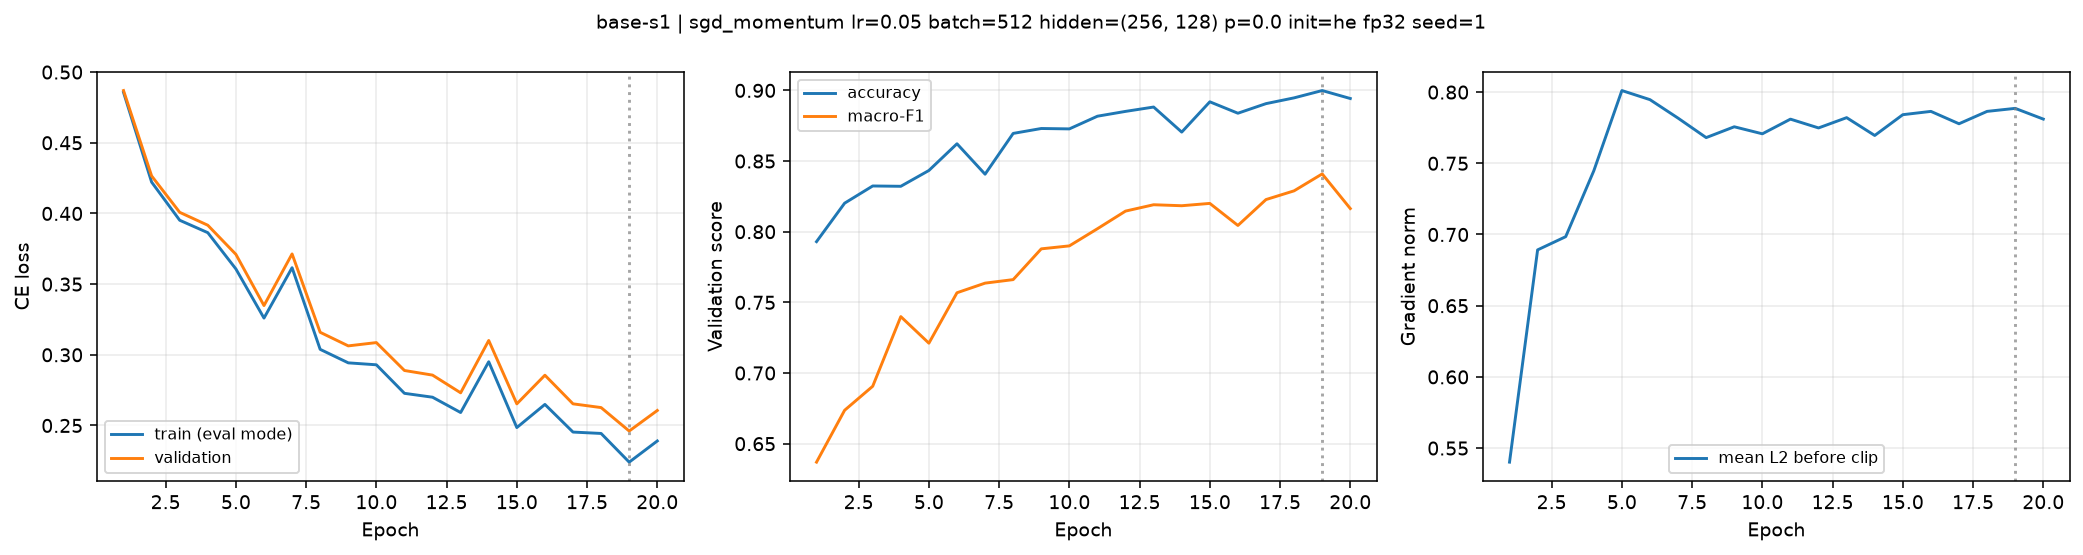

In [4]:
search_results = lab.search()
display(pd.DataFrame([dict(exp_id=r["cfg"]["exp_id"], optimizer=r["cfg"]["optimizer"], lr=r["cfg"]["lr"],
    best_epoch=r["summary"]["best_epoch"], val_f1=r["summary"]["val_macro_f1"]) for r in search_results]))
baselines = [lab.run(lab.baseline_cfg(s)) for s in (1, 2, 3)]
base_f1 = np.array([r["summary"]["val_macro_f1"] for r in baselines])
noise = 2 * base_f1.std(ddof=1)
print("Baseline F1 mean ± sample std:", base_f1.mean(), base_f1.std(ddof=1), "2 sigma:", noise)
display(Image(filename=str(OUT_DIR / "figures/base-s1.png")))

## Part 3 — Thí nghiệm

Mỗi cấu hình ghi giả thuyết trước khi chạy; giữ split/seed/budget. Cặp lr cao chỉ khác clipping trong cặp. Ngưỡng clipping lấy từ baseline. FP16 dùng GradScaler và unscale trước đo/clip; BF16 chỉ chạy nếu có phần cứng native.

### Giả thuyết trước các thí nghiệm

**loss:** MSE trên logits và one-hot có thang đo khác CE; có thể hội tụ chậm hoặc khác về macro-F1. So bằng metric, không so loss tuyệt đối.

**hparam:** M-wide tăng năng lực biểu diễn, có thể tăng macro-F1 nhưng tốn thời gian và bộ nhớ hơn; chưa chắc có lợi nếu chưa hội tụ.

**dropout:** Dropout 0.3 có thể giảm gap nếu baseline quá khớp; nếu train và val vẫn cùng giảm thì có thể làm chậm học.

**clipping:** Clip phải kích hoạt để có tác dụng. Ở lr cao, giới hạn chuẩn gradient có thể giảm dao động nhưng không bảo đảm cứu được huấn luyện.

**amp:** FP16 có thể giảm bộ nhớ, nhưng mạng nhỏ và GPU này có thể không nhanh hơn; chất lượng kỳ vọng gần FP32.

**init:** Zeros giữ đối xứng và ReLU tại 0 chặn gradient lớp ẩn. Xavier/normal thay đổi phương sai kích hoạt và tốc độ học so với He.

**final:** Cấu hình đã chọn bằng validation có thể dao động giữa seed; lặp seed 2 và 3 để đo nhiễu, không chọn lại theo eval.

Reuse measured run base-s1


Reuse measured run base-s2


Reuse measured run base-s3


Reuse measured run loss-mse


Reuse measured run wide


...

Reuse measured run init-zeros


Reuse measured run init-normal


Reuse measured run init-xavier


Reuse measured run amp-fp16


,exp_id,group,f1,delta_vs_base_mean,beyond_2sigma,time_s,diverged
0,amp-fp16,amp,0.831873,-0.008707,False,2.283342,False
1,base-s1,baseline,0.840900,0.000320,False,1.983740,False
2,base-s2,baseline,0.834267,-0.006313,False,1.982907,False
3,base-s3,baseline,0.846572,0.005992,False,2.001571,False
4,clip-normal,clipping,0.802991,-0.037589,True,1.778565,False
5,drop-0.3,dropout,0.751938,-0.088642,True,1.962665,False
6,final-s2,final,0.873193,0.032613,True,8.296690,False
7,final-s3,final,0.878305,0.037725,True,6.958480,False
8,highlr-clip,clipping,0.852861,0.012281,False,1.682972,False
9,highlr-no-clip,clipping,0.824750,-0.015830,True,1.781073,False


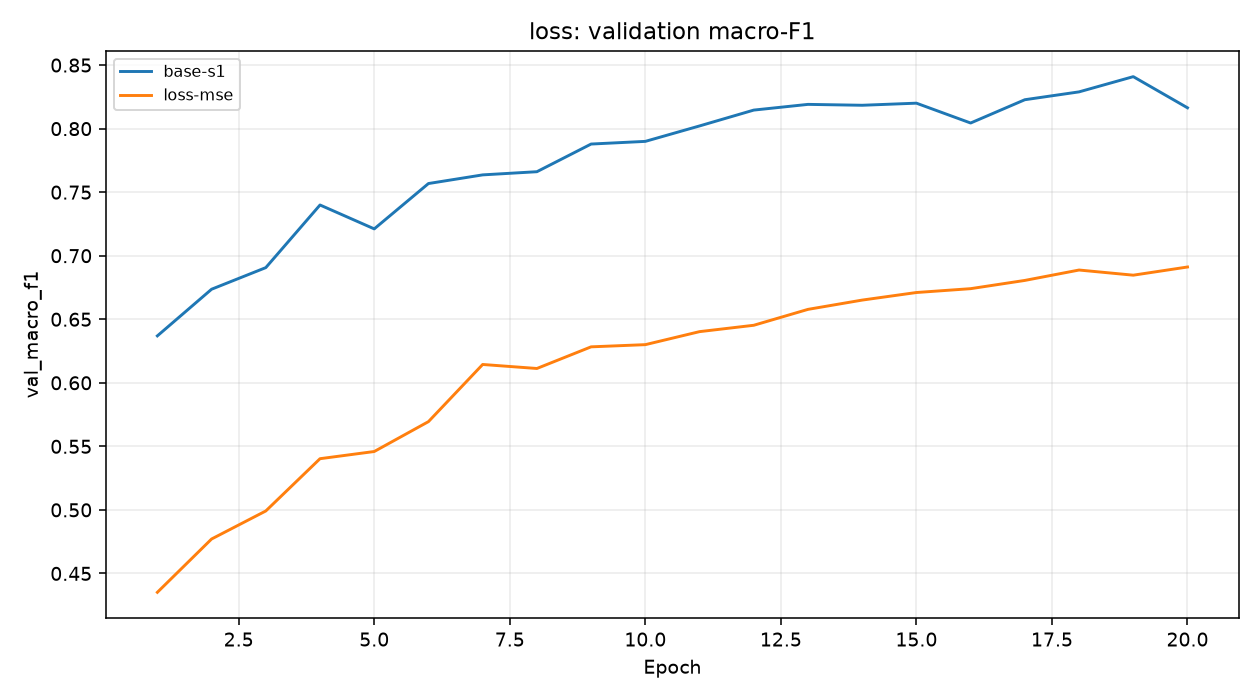

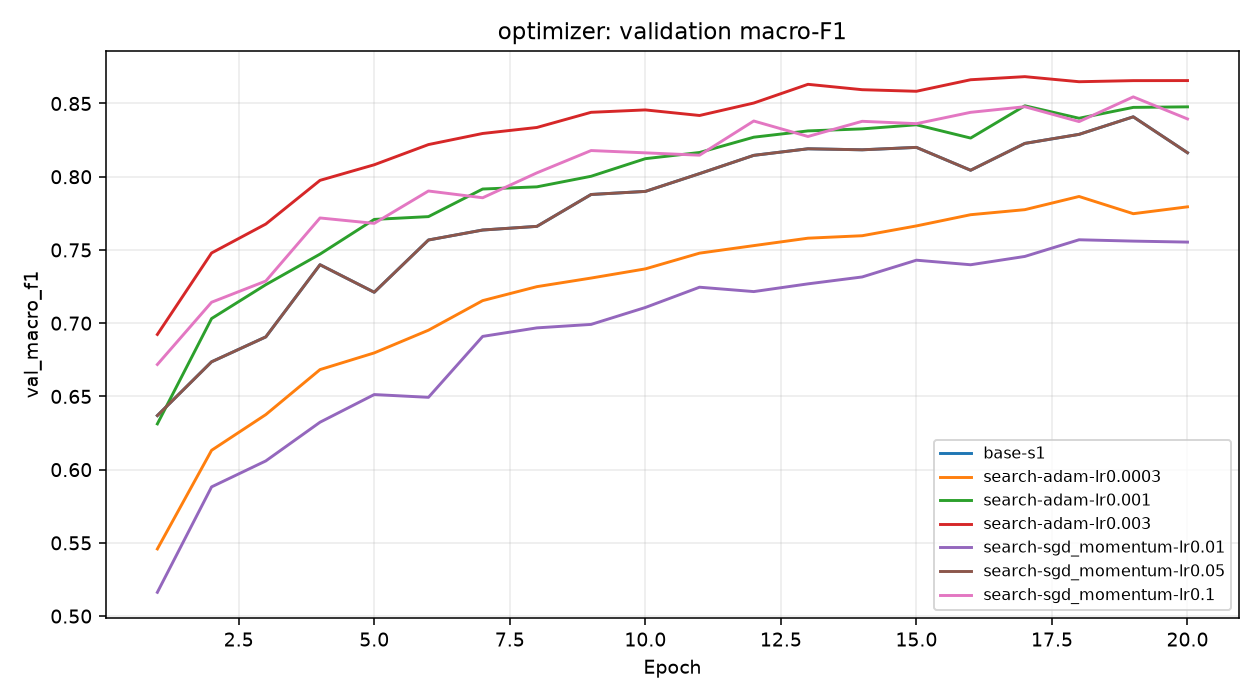

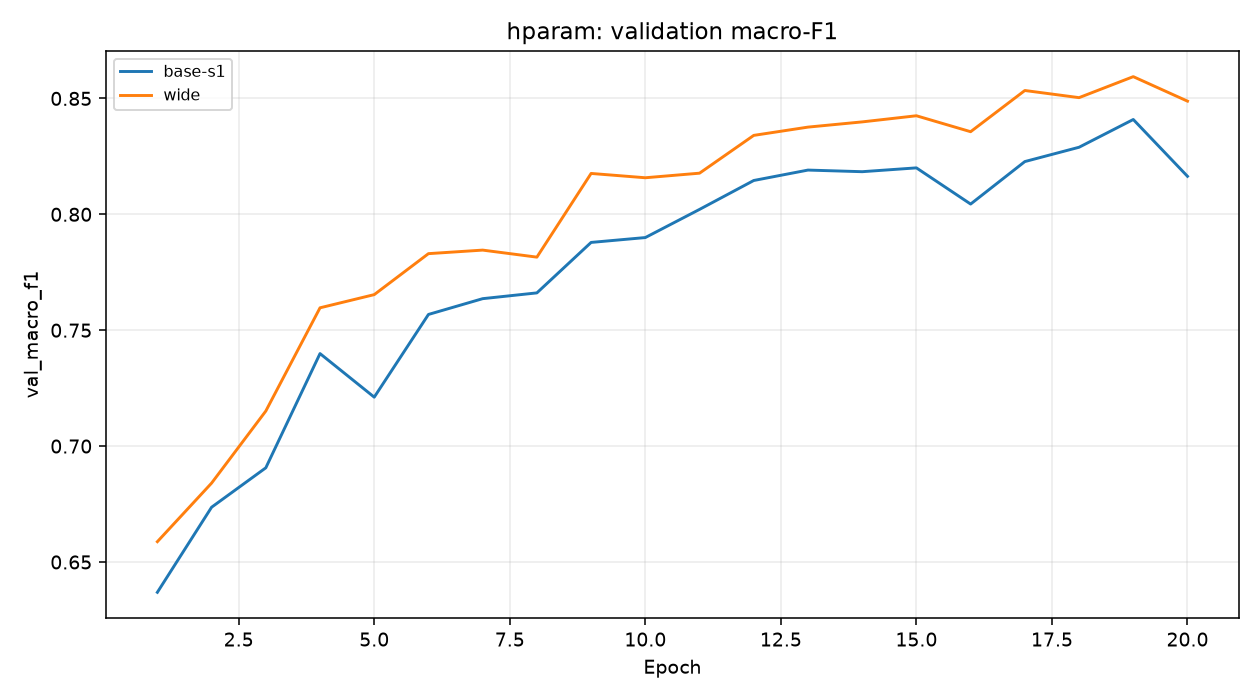

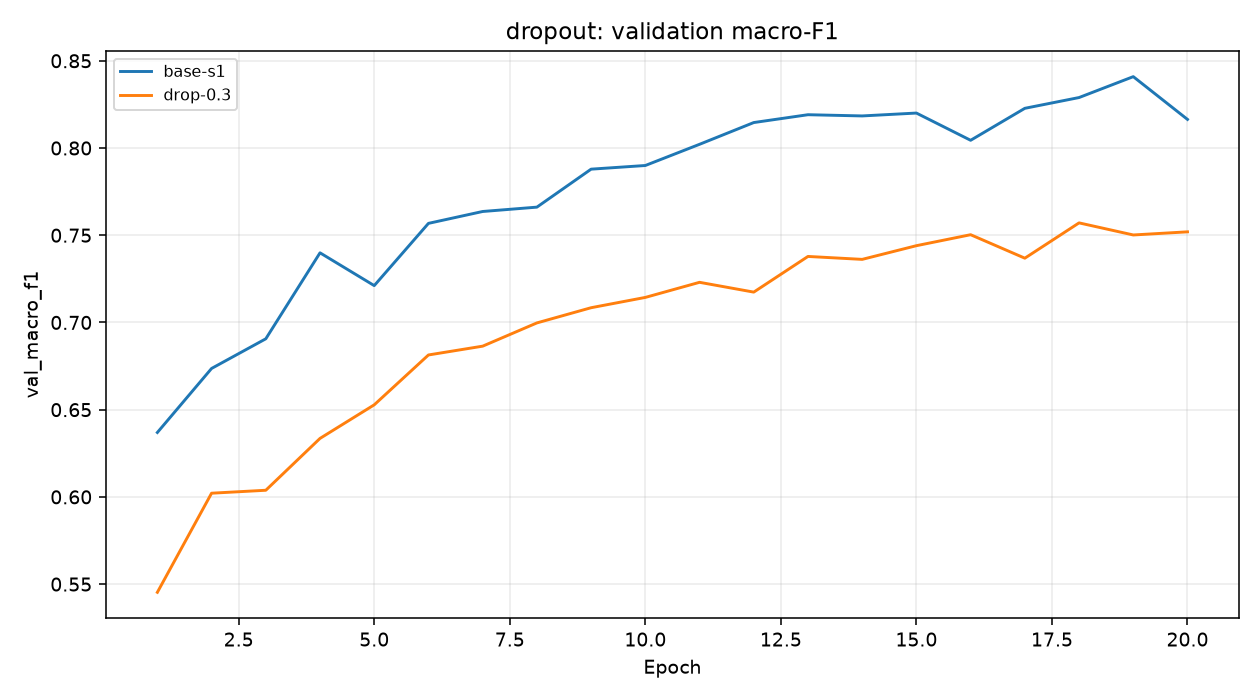

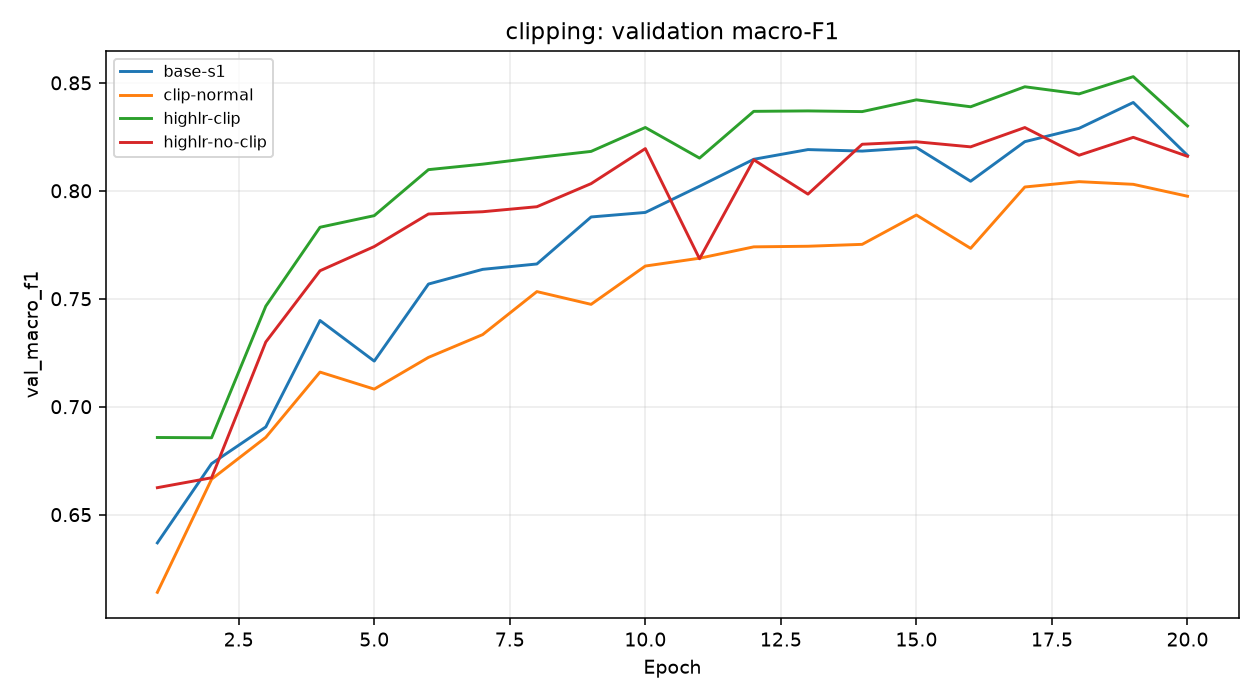

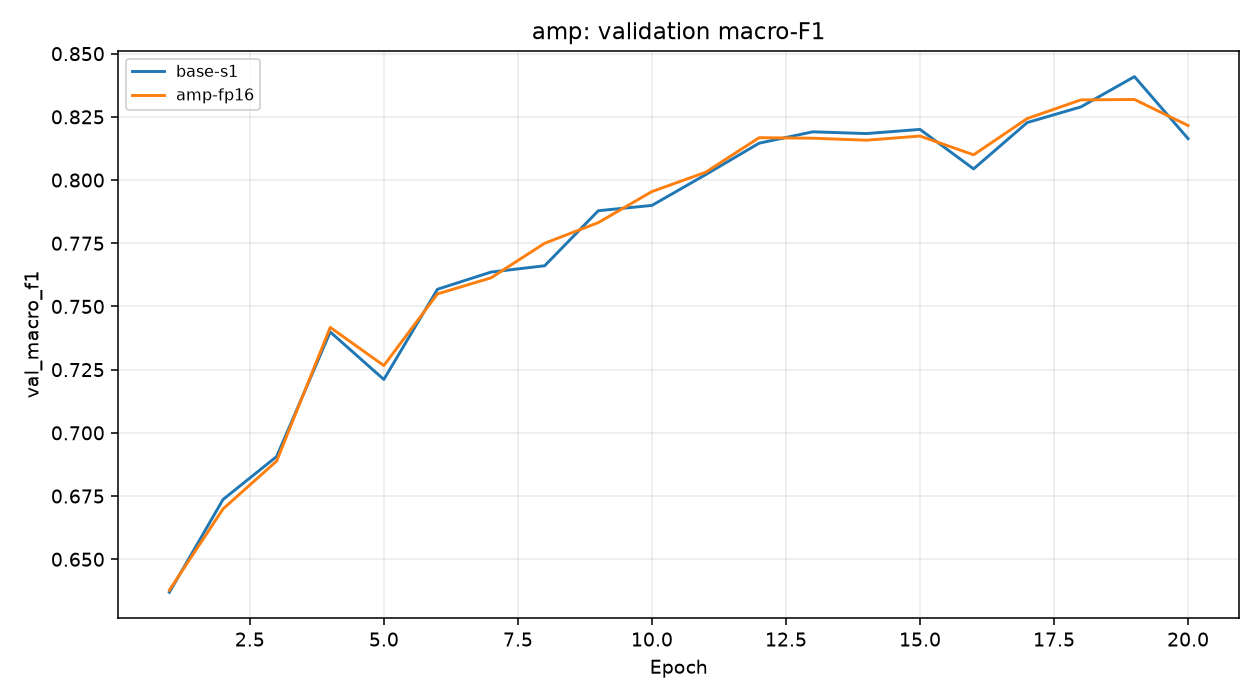

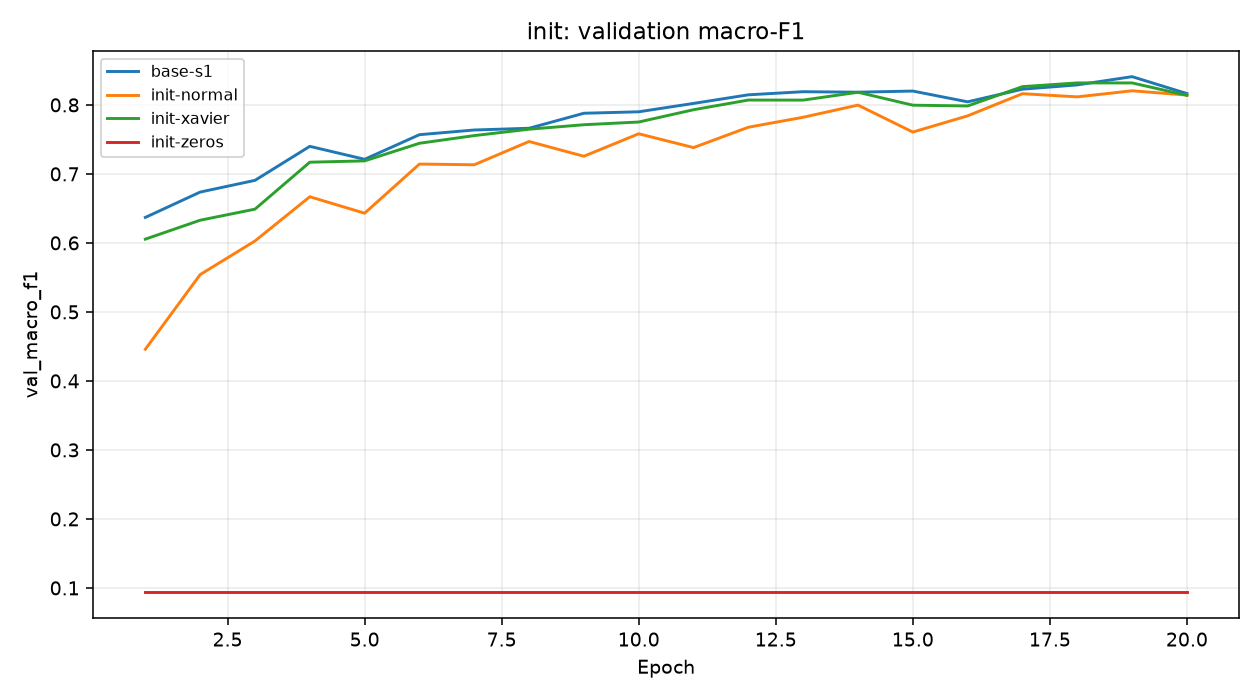

In [5]:
topic_results = lab.topics()
all_results = load_results(OUT_DIR / "results")
display(pd.DataFrame([dict(exp_id=r["cfg"]["exp_id"], group=r["cfg"]["group"],
    f1=r["summary"]["val_macro_f1"], delta_vs_base_mean=r["summary"]["val_macro_f1"]-base_f1.mean(),
    beyond_2sigma=abs(r["summary"]["val_macro_f1"]-base_f1.mean())>noise,
    time_s=r["summary"]["time_per_epoch_s"], diverged=r["summary"]["diverged"]) for r in all_results]))
for group in ("loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init"):
    figure = OUT_DIR / "figures" / f"compare_{group}.png"
    if figure.exists(): display(Image(filename=str(figure)))

### Đối chiếu sau chạy

`amp-fp16`: val macro-F1 0.831873, best epoch 19, diverged False.

`base-s1`: val macro-F1 0.840900, best epoch 19, diverged False.

`base-s2`: val macro-F1 0.834267, best epoch 20, diverged False.

`base-s3`: val macro-F1 0.846572, best epoch 20, diverged False.

`clip-normal`: val macro-F1 0.802991, best epoch 19, diverged False.

`drop-0.3`: val macro-F1 0.751938, best epoch 20, diverged False.

`final-s2`: val macro-F1 0.873193, best epoch 20, diverged False.

`final-s3`: val macro-F1 0.878305, best epoch 20, diverged False.

`highlr-clip`: val macro-F1 0.852861, best epoch 19, diverged False.

`highlr-no-clip`: val macro-F1 0.824750, best epoch 19, diverged False.

`init-normal`: val macro-F1 0.814217, best epoch 20, diverged False.

`init-xavier`: val macro-F1 0.831787, best epoch 19, diverged False.

`init-zeros`: val macro-F1 0.093650, best epoch 8, diverged False.

`loss-mse`: val macro-F1 0.691116, best epoch 20, diverged False.

`search-adam-lr0.0003`: val macro-F1 0.779439, best epoch 20, diverged False.

`search-adam-lr0.001`: val macro-F1 0.847708, best epoch 20, diverged False.

`search-adam-lr0.003`: val macro-F1 0.865647, best epoch 20, diverged False.

`search-sgd_momentum-lr0.01`: val macro-F1 0.756035, best epoch 19, diverged False.

`search-sgd_momentum-lr0.05`: val macro-F1 0.840900, best epoch 19, diverged False.

`search-sgd_momentum-lr0.1`: val macro-F1 0.839460, best epoch 20, diverged False.

`wide`: val macro-F1 0.848815, best epoch 20, diverged False.

Các giá trị trên là lịch sử của bộ nộp hiện tại; nếu huấn luyện lại, dùng bảng output mới. Giải thích cơ chế, điều khác dự đoán và giới hạn một seed mỗi kỹ thuật nằm ở REPORT.md.

## Part 4 — Khóa lựa chọn, eval và bộ nộp

Chọn cấu hình bằng val F1 tại checkpoint có val loss thấp nhất; khóa exp_id trước evaluate.py. Chấm baseline và cấu hình cuối. Không điều chỉnh sau khi thấy eval.

Reuse measured run final-s2


Reuse measured run final-s3


Reuse fixed official score baseline_eval_result.json; selection remains frozen


Reuse fixed official score eval_result.json; selection remains frozen


Reuse fixed official score eval_base_s2.json; selection remains frozen


Reuse fixed official score eval_final_s2.json; selection remains frozen


Reuse fixed official score eval_base_s3.json; selection remains frozen


Reuse fixed official score eval_final_s3.json; selection remains frozen


Fixed selected experiment: search-adam-lr0.003
Official accuracy/macro-F1: 0.9149591662865847 0.8639753256014941


,cls,support,precision,recall,f1
0,0,42368,0.908227,0.915408,0.911803
1,1,56661,0.927523,0.930552,0.929035
2,2,7151,0.887924,0.929520,0.908246
3,3,549,0.879271,0.703097,0.781377
4,4,1899,0.823837,0.746182,0.783089
5,5,3473,0.869792,0.769364,0.816501
6,6,4102,0.937008,0.899317,0.917776


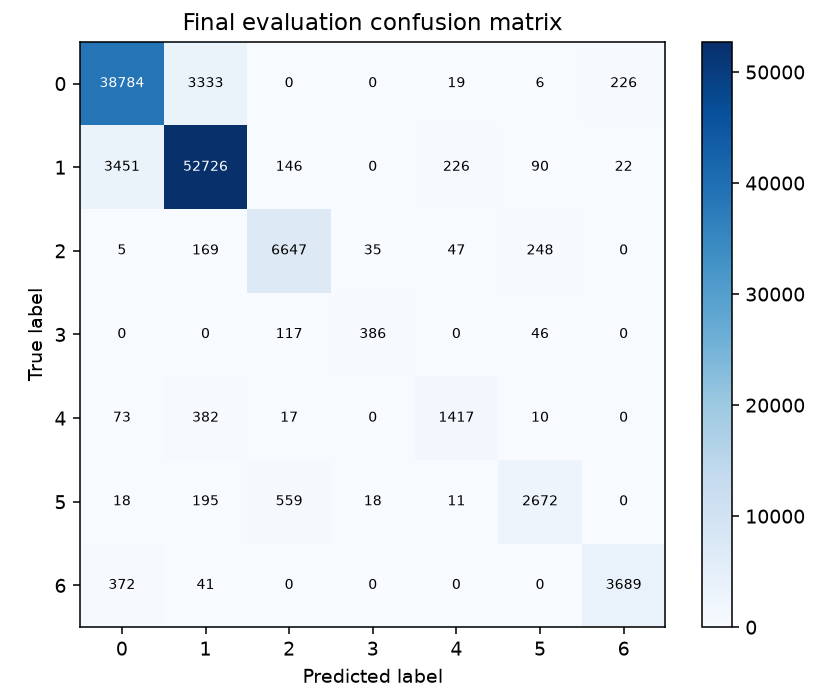

# Báo cáo Lab Day 1 — Chưa cung cấp họ tên — MSSV

## 1. Thiết lập

Forest CoverType: train/eval cố định 464.809/116.203; tách val 20%, stratified seed 42 → train 371.847, val 92.962. Chuẩn hóa 10 cột số bằng mean/std của train sau tách; 44 cột nhị phân giữ nguyên. Eval chỉ dùng sau khi khóa lựa chọn bằng val.

Môi trường: Windows-11-10.0.26200-SP0; Python 3.13.0, PyTorch 2.7.1+cu126, GPU NVIDIA GeForce GTX 1650. M-base 54→256→128→7, ReLU, 47.879 tham số. Baseline: CE, SGD momentum 0,9, lr=0.05, He cho mọi Linear, bias=0, batch=512, 20 epoch, không dropout/clip, FP32, weight decay=0. Đoán đa số trên val: accuracy=0.487597 (run_manifest.json; notes baseline trong bảng).

Train loss đo ở eval mode trên 50.000 dòng cố định; val đo toàn bộ. Giữ batch cuối nhỏ hơn 512. Best checkpoint theo val loss nhỏ nhất; bảng ghi acc/F1 ở checkpoint này. MSE là trung bình trên N×7 phần tử của logits thô so one-hot.

## 2. Kiểm tra ban đầu và độ nhiễu

Shape logits (8,7), assert 47879 tham số; mọi gradient khác 0 (chi tiết trong notebook). Loss CE bước 0=2.269062, so với ln7=1,945910. ln7 chỉ đúng cho dự đoán đều; He ở lớp cuối có thể tạo logits không đều nên không ép loss về mốc này. Kiểm tra chuẩn hóa, gradient và học thuộc batch nhỏ dùng để loại trừ lỗi pipeline.

Học thuộc 20 mẫu cân bằng qua 600 bước Adam lr=0,01: loss=0.00000063, accuracy=1.0000; [đường cong](figures/health-overfit20.png). Đây là phép kiểm tra code, không chọn cấu hình bằng 20 mẫu.

Baseline 3 seed (`base-s1`, `base-s2`, `base-s3`): val macro-F1=0.840580 ± 0.006159; ngưỡng tham khảo 2σ=0.012317. Val accuracy=0.901895 ± 0.002442. Đây là thước đo dao động baseline với 3 seed, chưa phải kiểm định thống kê hay độ nhiễu riêng của mỗi kỹ thuật.

Đường baseline: train loss cuối=0.239038, val loss cuối=0.260604, best epoch=19/20. Epoch tốt nhất gần cuối, gợi ý mô hình còn có thể học thêm; chưa có dấu hiệu quá khớp kéo dài chỉ từ đường này. [Ảnh baseline](figures/base-s1.png).

## 3. Kết quả theo chủ đề

Mọi dự đoán được ghi trong experiment_plan.py và run_manifest.json trước tối ưu. Mọi phép so sánh dưới đây dựa trên val; mỗi exp_id có dòng Excel và ảnh riêng. Các run dò lr cũng chạy 20 epoch.

| Chủ đề | exp_id đại diện | best epoch | val macro-F1 | Δ so base-s1 |
|---|---|---:|---:|---:|
| loss | `loss-mse` | 20 | 0.691116 | -0.149784 |
| optimizer | `search-adam-lr0.003` | 20 | 0.865647 | +0.024747 |
| hparam | `wide` | 20 | 0.848815 | +0.007915 |
| dropout | `drop-0.3` | 20 | 0.751938 | -0.088962 |
| clipping | `highlr-clip` | 19 | 0.852861 | +0.011961 |
| amp | `amp-fp16` | 19 | 0.831873 | -0.009027 |
| init | `init-xavier` | 19 | 0.831787 | -0.009113 |

### loss

**Dự đoán:** MSE trên logits và one-hot có thang đo khác CE; có thể hội tụ chậm hoặc khác về macro-F1. So bằng metric, không so loss tuyệt đối.

**Đối chiếu:** MSE đạt F1=0.691116; CE và MSE không có cùng đơn vị loss. CE tác động qua xác suất lớp, còn MSE logits phạt khoảng cách tới one-hot và phụ thuộc thang logits; cố định lr CE ở MSE chỉ kiểm tra thay loss tại cấu hình này, chưa tối ưu lr riêng cho MSE.

Chênh lệch đại diện -0.149784 vượt 2σ baseline; [ảnh so sánh](figures/compare_loss.png).

### optimizer

**Dự đoán:** Adam điều chỉnh bước theo từng tham số nên có thể hội tụ nhanh hơn SGD momentum, nhưng phải thử lr riêng cho mỗi optimizer.

**Đối chiếu:** mỗi optimizer được thử 3 lr; so lựa chọn tốt nhất bằng val macro-F1:

| Optimizer | exp_id | lr | val F1 |
|---|---|---:|---:|
| sgd_momentum | `search-sgd_momentum-lr0.05` | 0.05 | 0.840900 |
| adam | `search-adam-lr0.003` | 0.003 | 0.865647 |

Adam dùng moment bậc một và hai (betas 0,9/0,999; eps 1e-8), thay đổi bước theo từng tham số; momentum tích lũy hướng gradient. Khác biệt quan sát phụ thuộc cả optimizer và lr đã dò. Không thử AdamW nên không kết luận thực nghiệm về Adam so AdamW.

Chênh lệch đại diện +0.024747 vượt 2σ baseline; [ảnh so sánh](figures/compare_optimizer.png).

### hparam

**Dự đoán:** M-wide tăng năng lực biểu diễn, có thể tăng macro-F1 nhưng tốn thời gian và bộ nhớ hơn; chưa chắc có lợi nếu chưa hội tụ.

**Đối chiếu:** M-wide 161.287 tham số đạt F1=0.848815; 1.75s/epoch so baseline 1.98s. Cùng batch, số epoch và số bước cập nhật; năng lực biểu diễn lớn hơn cũng tăng chi phí tính toán. 20 epoch không bảo đảm các kiến trúc đều hội tụ.

Thời gian M-wide trong lần đo này lại thấp hơn baseline, khác dự đoán về wall time. Số phép toán lớn hơn không quyết định trực tiếp thời gian của mạng nhỏ trên GPU; chi phí kernel và điều kiện máy là giả thuyết, chưa kiểm chứng bằng benchmark lặp.

Chênh lệch đại diện +0.007915 không vượt 2σ baseline; [ảnh so sánh](figures/compare_hparam.png).

### dropout

**Dự đoán:** Dropout 0.3 có thể giảm gap nếu baseline quá khớp; nếu train và val vẫn cùng giảm thì có thể làm chậm học.

**Đối chiếu:** gap cuối baseline=0.021566, dropout 0,3=0.002823; F1 dropout=0.751938. Dropout làm nhiễu biểu diễn khi train, giúp chống quá khớp nhưng cũng có thể làm chậm học. Gap nhỏ riêng lẻ chưa đủ để kết luận tổng quát hóa tốt hơn.

Chênh lệch đại diện -0.088962 vượt 2σ baseline; [ảnh so sánh](figures/compare_dropout.png).

### clipping

**Dự đoán:** Clip phải kích hoạt để có tác dụng. Ở lr cao, giới hạn chuẩn gradient có thể giảm dao động nhưng không bảo đảm cứu được huấn luyện.

**Đối chiếu:** c=0.389693, bằng nửa trung vị mean grad_norm baseline; tỉ lệ bước bị clip ở lr thường=0.9946. `highlr-no-clip` và `highlr-clip` cùng lr=0.5, chỉ khác clipping; đo grad trước clip.

`highlr-no-clip`: F1=0.824750, completed=20, diverged=False.

`highlr-clip`: F1=0.852861, completed=20, diverged=False.

Clipping giới hạn chuẩn L2 toàn cục, không đổi hướng; lr cao vẫn có thể gây dao động vì bước cập nhật và momentum. Việc không phát sinh NaN không đồng nghĩa đã hội tụ tốt.

Trong cặp lr cao, clip kích hoạt ở trung bình 0.0198 số bước, chênh F1=+0.028111. Không run nào NaN: phép thử không chứng minh clipping cứu phân kỳ; chỉ cho thấy thay đổi quỹ đạo học. Ngược lại, clip lr thường kích hoạt gần mọi bước, có thể giới hạn bước quá mạnh và làm chậm học.

Chênh lệch đại diện +0.011961 không vượt 2σ baseline; [ảnh so sánh](figures/compare_clipping.png).

### amp

**Dự đoán:** FP16 có thể giảm bộ nhớ, nhưng mạng nhỏ và GPU này có thể không nhanh hơn; chất lượng kỳ vọng gần FP32.

**Đối chiếu:** FP16 2.28s/epoch, peak 159.42 MB; FP32 1.98s, peak 159.41 MB. F1 FP16=0.831873. FP16 không nhanh hơn trong lần đo này. Mạng nhỏ chịu chi phí kernel/autocast; không suy rộng sang mạng lớn. FP16 cần loss scaling để hạn chế underflow; unscale trước khi đo/clip. BF16 có khoảng số rộng hơn và thường không cần scaler, nhưng GPU này không có BF16 native nên không chạy. Peak bao gồm tensor dữ liệu cùng nằm trên GPU.

Chênh lệch đại diện -0.009027 không vượt 2σ baseline; [ảnh so sánh](figures/compare_amp.png).

### init

**Dự đoán:** Zeros giữ đối xứng và ReLU tại 0 chặn gradient lớp ẩn. Xavier/normal thay đổi phương sai kích hoạt và tốc độ học so với He.

**Đối chiếu:** std sau mỗi hidden ReLU và logits cuối tại bước 0:

| Init / exp_id | std theo lớp | CE bước 0 |
|---|---|---:|
| he / `base-s1` | 0.39045, 0.36609, 0.57593 | 2.269062 |
| xavier / `init-xavier` | 0.16296, 0.12475, 0.19111 | 2.022176 |
| normal / `init-normal` | 0.02029, 0.00215, 0.00027 | 1.945996 |
| zeros / `init-zeros` | 0.00000, 0.00000, 0.00000 | 1.945915 |

Zeros khiến hidden activation và gradient lớp ẩn bằng 0; chỉ bias đầu ra học được tần suất lớp. Normal std=0,01 dễ làm tín hiệu nhỏ qua nhiều lớp. He có Var=2/fan_in để bù ReLU, Xavier dùng 2/(fan_in+fan_out). Mạng chỉ hai lớp ẩn nên chưa đại diện cho hiện tượng suy giảm/bùng nổ ở mạng rất sâu.

Chênh lệch đại diện -0.009113 không vượt 2σ baseline; [ảnh so sánh](figures/compare_init.png).

## 4. Đánh giá cuối trên eval

Khóa cấu hình `search-adam-lr0.003`, seed 1 bằng val F1=0.865647, checkpoint epoch 20, trước khi gọi evaluate.py. Không chỉnh cấu hình sau eval.

| Cấu hình | eval accuracy | eval macro-F1 |
|---|---:|---:|
| Baseline `base-s1` | 0.899194 | 0.844278 |
| Cuối `search-adam-lr0.003` | 0.914959 | 0.863975 |

Cải thiện eval F1=+0.019697. Chênh val–eval của mô hình cuối =+0.001672. Cố định seed 1 cho file nộp, không chọn seed theo eval. Seed 2/3 của cùng cấu hình (`final-s2`, `final-s3`) chỉ đo nhiễu; cấu hình đã khóa trước khi chạy eval.

Eval F1 qua seed 1/2/3: baseline=0.845884 ± 0.004742, cuối=0.873206 ± 0.009263; cải thiện ghép cặp=+0.027322 ± 0.006605; 2σ của chênh lệch=0.013209. Cải thiện trung bình vượt ngưỡng nhiễu tham khảo này. Ba seed là mẫu nhỏ; đây chưa phải kiểm định thống kê đầy đủ. Mỗi số eval lấy từ script chính thức và có cột eval tương ứng trong Excel.

### Phân tích lỗi theo lớp

| Lớp | support | precision | recall | F1 |
|---|---:|---:|---:|---:|
| 0 | 42368 | 0.908227 | 0.915408 | 0.911803 |
| 1 | 56661 | 0.927523 | 0.930552 | 0.929035 |
| 2 | 7151 | 0.887924 | 0.929520 | 0.908246 |
| 3 | 549 | 0.879271 | 0.703097 | 0.781377 |
| 4 | 1899 | 0.823837 | 0.746182 | 0.783089 |
| 5 | 3473 | 0.869792 | 0.769364 | 0.816501 |
| 6 | 4102 | 0.937008 | 0.899317 | 0.917776 |

Lớp khó nhất 3 (F1=0.781377, support=549); nhầm sang lớp 2 nhiều nhất (117 mẫu). Mất cân bằng và đặc trưng địa hình chồng lấn là các giả thuyết, chưa kiểm chứng quan hệ nhân quả. Có thể thử weighted CE chỉ bằng val trong nghiên cứu tiếp theo.

![Ma trận nhầm lẫn](figures/eval-confusion.png)

## 5. Câu hỏi dẫn dắt và hạn chế

Optimizer tốt nhất và tác dụng dropout/clipping/AMP được trả lời bằng số ở mục 3; không có một kỹ thuật luôn thắng cho mọi lr, mức quá khớp hay phần cứng. AdamW khác Adam ở weight decay tách riêng, nhưng chưa thử ở đây.

**Loss không giảm sau 2.000 bước: ba kiểm tra đầu tiên.** (1) Kiểm tra shape, dtype, nhãn 0..6, chuẩn hóa train-only và loss trước cập nhật để phát hiện dữ liệu/logits sai. (2) Tắt regularization rồi học thuộc 20 mẫu; nếu thất bại, kiểm tra zero_grad, optimizer và backward trước khi tăng năng lực model. (3) In gradient từng lớp, grad_norm trước clip và đường train/val; gradient 0 gợi ý ReLU chết/đứt graph, gradient lớn/NaN gợi ý lr hoặc precision, train thấp nhưng val tăng gợi ý quá khớp.

Baseline và cấu hình cuối có 3 seed; các phép so sánh kỹ thuật còn lại chủ yếu 1 seed, 3 lr mỗi optimizer chưa phải tìm kiếm đầy đủ. Thời gian mỗi epoch gồm cả đánh giá train/val, chịu ảnh hưởng nhiệt độ và tác vụ nền; chưa benchmark nhiều lần. Best epoch theo val loss có thể khác epoch F1 cao nhất. Phép thử lr×10 không đảm bảo tạo NaN; kết quả ổn định cũng phải ghi nhận. Không kết luận nguyên nhân từ một quan sát tương quan.

Ngoại lệ thời gian `search-adam-lr0.001`: epoch dài nhất 3344.742s, trung vị 1.922s. Chưa xác định nguyên nhân gián đoạn; vẫn giữ mean và lịch sử gốc trong bảng/JSON, không dùng run này để kết luận tốc độ optimizer.

## 6. Phụ lục

21 lần chạy so sánh, mỗi lần một JSON/ảnh/dòng Excel. Thời gian huấn luyện và đánh giá epoch tổng cộng 72.89 phút (không tính setup/health/xuất file). Có REPORT.md, experiments.xlsx, predictions_eval.csv, eval_result.json, baseline_eval_result.json, run_manifest.json, figures/, results/, code/. Trọng số chỉ lưu ở .work ngoài bộ nộp. Notebook có thể dùng lại lịch sử đã đo; REUSE_RESULTS=False huấn luyện lại trong thư mục mới.


In [6]:
eval_scores = lab.finalize()
print("Fixed selected experiment:", lab.manifest["selected_exp_id"])
print("Official accuracy/macro-F1:", eval_scores["accuracy"], eval_scores["macro_f1"])
display(pd.DataFrame(eval_scores["per_class"]))
display(Image(filename=str(OUT_DIR / "figures/eval-confusion.png")))
display(Markdown((OUT_DIR / "REPORT.md").read_text(encoding="utf-8")))

In [7]:
from validate_submission import validate_submission
validate_submission(OUT_DIR, lab.repo)
print("Ready:", OUT_DIR / "experiments.xlsx", OUT_DIR / "predictions_eval.csv")

Submission validation passed: 21 experiment rows/plots, four-sheet formulas and caches, 116203 predictions, official scores matched.
Ready: C:\Users\ACER\K4-Track4-Day1-Neuralnetwork\submission_MSSV\experiments.xlsx C:\Users\ACER\K4-Track4-Day1-Neuralnetwork\submission_MSSV\predictions_eval.csv
